In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Critical Risks Monte Carlo Recalculation
# Based on updated Probability and Expected Loss
# Unit: $ Billion
# ==========================

np.random.seed(42)

critical_risks = {
    "Risk ID": ["R6", "R5", "R8", "R7"],
    "Risk Title": [
        "Legacy System Integration\nand Vendor Dependency",
        "Inventory Forecast Error,\nStockout & Fulfillment Disruption",
        "System Downtime and\nAI Platform Unavailability",
        "Customer Data Breach and\nInformation Security Risk"
    ],
    "Probability": [0.75, 0.68, 0.60, 0.45],
    "Expected Loss": [3.75, 5.20, 4.80, 3.60]
}

df_mc = pd.DataFrame(critical_risks)

n_simulations = 10000

mc_mean = []
mc_p90 = []

simulation_results = {}

for _, row in df_mc.iterrows():
    
    risk_id = row["Risk ID"]
    probability = row["Probability"]
    expected_loss = row["Expected Loss"]
    
    # Convert expected loss into conditional loss severity
    # Expected Loss = Probability × Conditional Severity
    conditional_mean_loss = expected_loss / probability
    
    # Loss severity range assumption
    # Low = 50% of conditional mean
    # Mode = 100% of conditional mean
    # High = 150% of conditional mean
    low = conditional_mean_loss * 0.5
    mode = conditional_mean_loss
    high = conditional_mean_loss * 1.5
    
    occurrence = np.random.binomial(
        n=1,
        p=probability,
        size=n_simulations
    )
    
    severity = np.random.triangular(
        left=low,
        mode=mode,
        right=high,
        size=n_simulations
    )
    
    simulated_loss = occurrence * severity
    
    simulation_results[risk_id] = simulated_loss
    
    mc_mean.append(simulated_loss.mean())
    mc_p90.append(np.percentile(simulated_loss, 90))

df_mc["Monte Carlo Mean"] = mc_mean
df_mc["Monte Carlo P90"] = mc_p90

df_mc

,Risk ID,Risk Title,Probability,Expected Loss,Monte Carlo Mean,Monte Carlo P90
0,R6,Legacy System Integration\nand Vendor Dependency,0.75,3.75,3.808535,6.250185
1,R5,"Inventory Forecast Error,\nStockout & Fulfillm...",0.68,5.20,5.240856,9.442804
2,R8,System Downtime and\nAI Platform Unavailability,0.60,4.80,4.828694,9.719169
3,R7,Customer Data Breach and\nInformation Security...,0.45,3.60,3.608366,9.332535


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Monte Carlo Recalculation for Critical Risks
# Unit: $ Billion
# ==========================

np.random.seed(42)

critical_risks = {
    "Risk ID": ["R6", "R5", "R8", "R7", "R14"],
    "Risk Title": [
        "Legacy System Integration\nand Vendor Dependency",
        "Inventory Forecast Error,\nStockout & Fulfillment Disruption",
        "System Downtime and\nAI Platform Unavailability",
        "Customer Data Breach and\nInformation Security Risk",
        "Regulatory Non-Compliance,\nShadow AI & AI Governance"
    ],
    "Probability": [0.75, 0.68, 0.60, 0.45, 0.55],
    "Expected Loss": [3.75, 5.20, 4.80, 3.60, 2.20]
}

df_mc = pd.DataFrame(critical_risks)

n_simulations = 10000

mc_mean = []
mc_p90 = []

for _, row in df_mc.iterrows():
    
    probability = row["Probability"]
    expected_loss = row["Expected Loss"]
    
    conditional_mean_loss = expected_loss / probability
    
    low = conditional_mean_loss * 0.5
    mode = conditional_mean_loss
    high = conditional_mean_loss * 1.5
    
    occurrence = np.random.binomial(
        n=1,
        p=probability,
        size=n_simulations
    )
    
    severity = np.random.triangular(
        left=low,
        mode=mode,
        right=high,
        size=n_simulations
    )
    
    simulated_loss = occurrence * severity
    
    mc_mean.append(simulated_loss.mean())
    mc_p90.append(np.percentile(simulated_loss, 90))

df_mc["Monte Carlo Mean"] = mc_mean
df_mc["Monte Carlo P90"] = mc_p90

df_mc

,Risk ID,Risk Title,Probability,Expected Loss,Monte Carlo Mean,Monte Carlo P90
0,R6,Legacy System Integration\nand Vendor Dependency,0.75,3.75,3.808535,6.250185
1,R5,"Inventory Forecast Error,\nStockout & Fulfillm...",0.68,5.20,5.240856,9.442804
2,R8,System Downtime and\nAI Platform Unavailability,0.60,4.80,4.828694,9.719169
3,R7,Customer Data Breach and\nInformation Security...,0.45,3.60,3.608366,9.332535
4,R14,"Regulatory Non-Compliance,\nShadow AI & AI Gov...",0.55,2.20,2.169721,4.755778


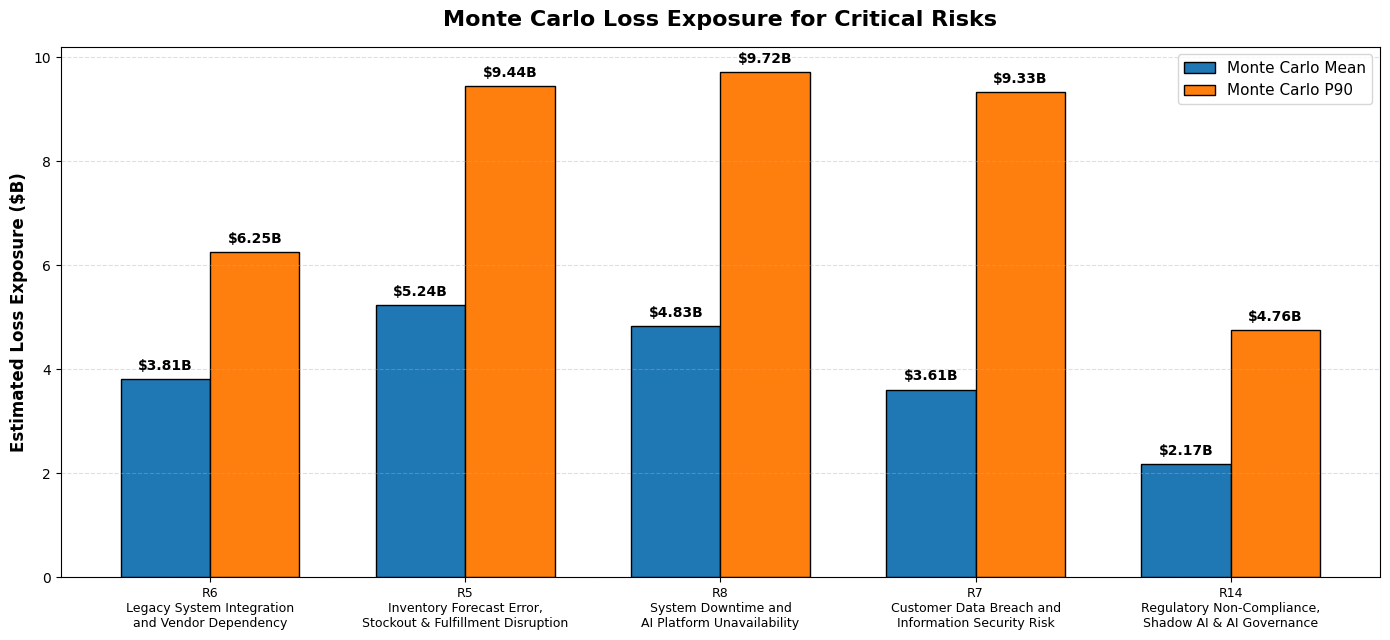

In [9]:
# ==========================
# Monte Carlo Mean vs P90 Chart
# ==========================

x = np.arange(len(df_mc))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6.5))

bars1 = ax.bar(
    x - width/2,
    df_mc["Monte Carlo Mean"],
    width,
    label="Monte Carlo Mean",
    edgecolor="black"
)

bars2 = ax.bar(
    x + width/2,
    df_mc["Monte Carlo P90"],
    width,
    label="Monte Carlo P90",
    edgecolor="black"
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.12,
            f"${height:.2f}B",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(
    df_mc["Risk ID"] + "\n" + df_mc["Risk Title"],
    fontsize=9
)

ax.set_ylabel(
    "Estimated Loss Exposure ($B)",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Monte Carlo Loss Exposure for Critical Risks",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder

# =====================================================
# 1. Final Critical Risks from Latest Risk Register
# =====================================================

critical_risks = pd.DataFrame({
    "Risk_ID": ["R5", "R6", "R8", "R7", "R14"],
    "Risk": [
        "Inventory Forecast Error, Stockout Risk and Fulfillment Disruption",
        "Legacy System Integration Failure and Vendor Dependency",
        "System Downtime and AI Platform Unavailability",
        "Customer Data Breach and Information Security Risk",
        "Regulatory Non-Compliance, Shadow AI and AI Governance Risk"
    ],
    "Risk_Category": [
        "Operational",
        "Technical",
        "Technical",
        "Cybersecurity",
        "Compliance"
    ],
    "Likelihood_Score": [7, 9, 7, 5, 7],
    "Impact_Score": [9, 9, 9, 9, 6],
    "Probability": [0.68, 0.62, 0.48, 0.45, 0.42],
    "Expected_Loss_B": [5.20, 3.10, 3.84, 3.60, 1.68],
    "Monte_Carlo_Mean_B": [5.24, 3.81, 4.83, 3.61, 2.17],
    "Monte_Carlo_P90_B": [9.44, 6.25, 9.72, 9.33, 4.76],
    "ML_Warning_Percent": [85.3, 78.4, 68.1, 65.0, 38.5]
})

critical_risks["Risk_Score"] = (
    critical_risks["Likelihood_Score"] * critical_risks["Impact_Score"]
)

critical_risks

,Risk_ID,Risk,Risk_Category,Likelihood_Score,Impact_Score,Probability,Expected_Loss_B,Monte_Carlo_Mean_B,Monte_Carlo_P90_B,ML_Warning_Percent,Risk_Score
0,R5,"Inventory Forecast Error, Stockout Risk and Fu...",Operational,7,9,0.68,5.20,5.24,9.44,85.3,63
1,R6,Legacy System Integration Failure and Vendor D...,Technical,9,9,0.62,3.10,3.81,6.25,78.4,81
2,R8,System Downtime and AI Platform Unavailability,Technical,7,9,0.48,3.84,4.83,9.72,68.1,63
3,R7,Customer Data Breach and Information Security ...,Cybersecurity,5,9,0.45,3.60,3.61,9.33,65.0,45
4,R14,"Regulatory Non-Compliance, Shadow AI and AI Go...",Compliance,7,6,0.42,1.68,2.17,4.76,38.5,42


In [14]:
# =====================================================
# 2. Generate 500 Simulated Risk Event Observations
# =====================================================

np.random.seed(42)

n_events = 500
simulated_rows = []

for _ in range(n_events):
    base = critical_risks.sample(1, weights=critical_risks["Probability"], replace=True).iloc[0]
    
    # Add realistic noise around final risk register assumptions
    likelihood = np.clip(
        np.random.normal(base["Likelihood_Score"], 1.0),
        1, 9
    )
    
    impact = np.clip(
        np.random.normal(base["Impact_Score"], 0.9),
        1, 9
    )
    
    probability = np.clip(
        np.random.normal(base["Probability"], 0.08),
        0.05, 0.95
    )
    
    expected_loss = max(
        0,
        np.random.normal(base["Expected_Loss_B"], base["Expected_Loss_B"] * 0.20)
    )
    
    monte_carlo_mean = max(
        0,
        np.random.normal(base["Monte_Carlo_Mean_B"], base["Monte_Carlo_Mean_B"] * 0.18)
    )
    
    monte_carlo_p90 = max(
        monte_carlo_mean,
        np.random.normal(base["Monte_Carlo_P90_B"], base["Monte_Carlo_P90_B"] * 0.15)
    )
    
    ml_warning = np.clip(
        np.random.normal(base["ML_Warning_Percent"], 8),
        0, 100
    )
    
    risk_score = likelihood * impact
    
    # Define target:
    # High risk escalation = 1 if risk has high score, high warning, or high financial exposure
    high_risk_event = int(
        (risk_score >= 40) or
        (ml_warning >= 65) or
        (monte_carlo_p90 >= 7)
    )
    
    simulated_rows.append({
        "Risk_ID": base["Risk_ID"],
        "Risk": base["Risk"],
        "Risk_Category": base["Risk_Category"],
        "Likelihood_Score": likelihood,
        "Impact_Score": impact,
        "Probability": probability,
        "Expected_Loss_B": expected_loss,
        "Monte_Carlo_Mean_B": monte_carlo_mean,
        "Monte_Carlo_P90_B": monte_carlo_p90,
        "ML_Warning_Percent": ml_warning,
        "Risk_Score": risk_score,
        "High_Risk_Event": high_risk_event
    })

df_sim = pd.DataFrame(simulated_rows)

print(df_sim.head())
print(df_sim["Risk_ID"].value_counts())
print(df_sim["High_Risk_Event"].value_counts())

  Risk_ID                                               Risk Risk_Category  \
0      R6  Legacy System Integration Failure and Vendor D...     Technical   
1      R8     System Downtime and AI Platform Unavailability     Technical   
2      R6  Legacy System Integration Failure and Vendor D...     Technical   
3      R5  Inventory Forecast Error, Stockout Risk and Fu...   Operational   
4      R6  Legacy System Integration Failure and Vendor D...     Technical   

   Likelihood_Score  Impact_Score  Probability  Expected_Loss_B  \
0          7.888120      9.000000     0.642323         3.726519   
1          6.075917      7.447574     0.435017         3.062146   
2          8.370525      9.000000     0.824759         3.344424   
3          7.947440      8.458464     0.828182         5.185963   
4          9.000000      9.000000     0.637491         3.646692   

   Monte_Carlo_Mean_B  Monte_Carlo_P90_B  ML_Warning_Percent  Risk_Score  \
0            3.411634           5.757653           7

In [15]:
# Optional: Save simulated dataset
df_sim.to_csv("walmart_critical_risk_simulated_500_events.csv", index=False)

In [16]:
# =====================================================
# 3. Random Forest Model
# =====================================================

df_model = df_sim.copy()

# Encode categorical features
le_category = LabelEncoder()
le_risk = LabelEncoder()

df_model["Risk_Category_Encoded"] = le_category.fit_transform(df_model["Risk_Category"])
df_model["Risk_ID_Encoded"] = le_risk.fit_transform(df_model["Risk_ID"])

features = [
    "Likelihood_Score",
    "Impact_Score",
    "Probability",
    "Expected_Loss_B",
    "Monte_Carlo_Mean_B",
    "Monte_Carlo_P90_B",
    "ML_Warning_Percent",
    "Risk_Score",
    "Risk_Category_Encoded",
    "Risk_ID_Encoded"
]

X = df_model[features]
y = df_model["High_Risk_Event"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.99      1.00      1.00       119

    accuracy                           0.99       125
   macro avg       1.00      0.92      0.95       125
weighted avg       0.99      0.99      0.99       125



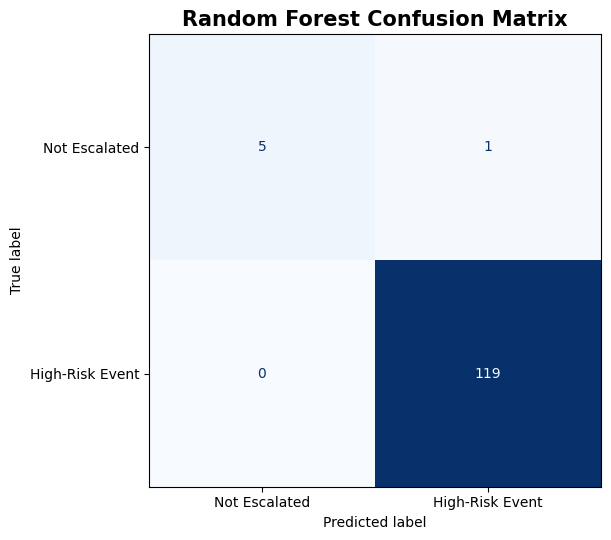

In [17]:
# =====================================================
# 4. Confusion Matrix
# =====================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6.5, 5.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Escalated", "High-Risk Event"]
)

disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title(
    "Random Forest Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("rf_confusion_matrix_critical_risks.png", dpi=300, bbox_inches="tight")
plt.show()

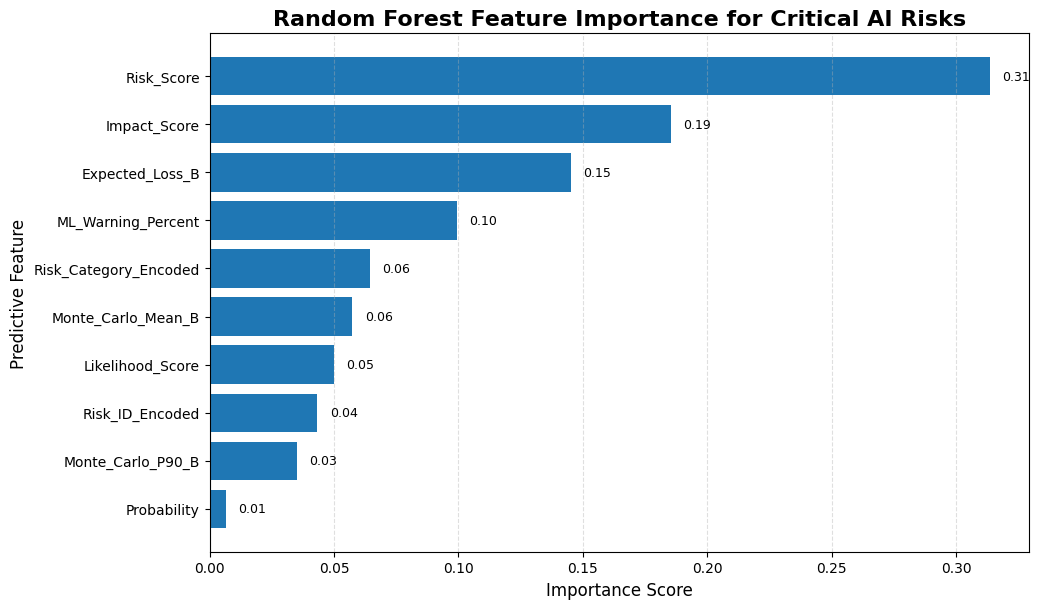

In [18]:
# =====================================================
# 5. Feature Importance Plot
# =====================================================

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 6.2))

ax.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

ax.set_title(
    "Random Forest Feature Importance for Critical AI Risks",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Importance Score", fontsize=12)
ax.set_ylabel("Predictive Feature", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(importance_df["Importance"]):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("rf_feature_importance_critical_risks.png", dpi=300, bbox_inches="tight")
plt.show()

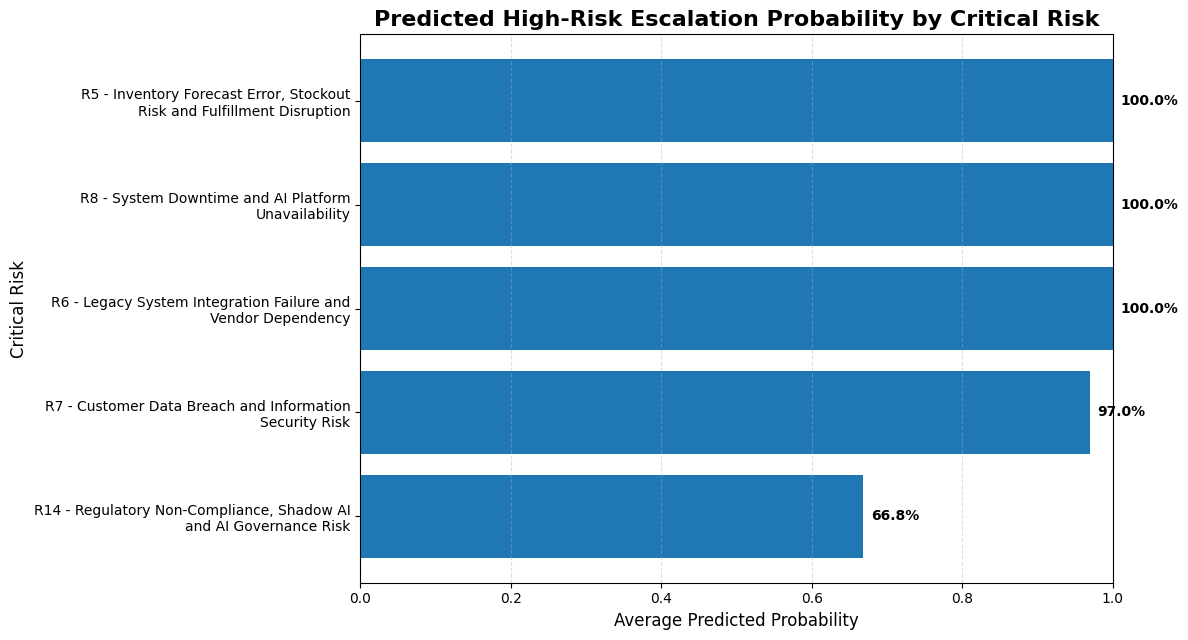

In [19]:
# =====================================================
# 6. Predicted High-Risk Probability by Critical Risk
# =====================================================

df_model["Predicted_High_Risk_Probability"] = rf.predict_proba(X)[:, 1]

risk_prediction = (
    df_model
    .groupby(["Risk_ID", "Risk"])["Predicted_High_Risk_Probability"]
    .mean()
    .reset_index()
    .sort_values("Predicted_High_Risk_Probability", ascending=True)
)

risk_prediction["Risk_Label"] = (
    risk_prediction["Risk_ID"] + " - " +
    risk_prediction["Risk"].str.wrap(38)
)

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.barh(
    risk_prediction["Risk_Label"],
    risk_prediction["Predicted_High_Risk_Probability"]
)

for i, v in enumerate(risk_prediction["Predicted_High_Risk_Probability"]):
    ax.text(
        v + 0.01,
        i,
        f"{v:.1%}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Predicted High-Risk Escalation Probability by Critical Risk",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Average Predicted Probability", fontsize=12)
ax.set_ylabel("Critical Risk", fontsize=12)
ax.set_xlim(0, 1)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("rf_predicted_probability_critical_risks.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# =====================================================
# 7. Summary Table for PPT
# =====================================================

summary_table = (
    df_model
    .groupby(["Risk_ID", "Risk"])
    .agg(
        Avg_Likelihood=("Likelihood_Score", "mean"),
        Avg_Impact=("Impact_Score", "mean"),
        Avg_Probability=("Probability", "mean"),
        Avg_Expected_Loss_B=("Expected_Loss_B", "mean"),
        Avg_P90_B=("Monte_Carlo_P90_B", "mean"),
        Avg_ML_Warning=("ML_Warning_Percent", "mean"),
        Predicted_High_Risk_Probability=("Predicted_High_Risk_Probability", "mean")
    )
    .reset_index()
    .sort_values("Predicted_High_Risk_Probability", ascending=False)
)

summary_table["Avg_Probability"] = summary_table["Avg_Probability"].map(lambda x: f"{x:.1%}")
summary_table["Avg_Expected_Loss_B"] = summary_table["Avg_Expected_Loss_B"].map(lambda x: f"${x:.2f}B")
summary_table["Avg_P90_B"] = summary_table["Avg_P90_B"].map(lambda x: f"${x:.2f}B")
summary_table["Avg_ML_Warning"] = summary_table["Avg_ML_Warning"].map(lambda x: f"{x:.1f}%")
summary_table["Predicted_High_Risk_Probability"] = summary_table["Predicted_High_Risk_Probability"].map(lambda x: f"{x:.1%}")

summary_table

,Risk_ID,Risk,Avg_Likelihood,Avg_Impact,Avg_Probability,Avg_Expected_Loss_B,Avg_P90_B,Avg_ML_Warning,Predicted_High_Risk_Probability
1,R5,"Inventory Forecast Error, Stockout Risk and Fu...",7.135114,8.650994,68.7%,$5.20B,$9.21B,86.1%,100.0%
4,R8,System Downtime and AI Platform Unavailability,6.970990,8.769860,48.4%,$3.89B,$9.75B,69.2%,100.0%
2,R6,Legacy System Integration Failure and Vendor D...,8.605564,8.681912,62.4%,$3.14B,$6.15B,78.9%,100.0%
3,R7,Customer Data Breach and Information Security ...,4.794079,8.642332,45.0%,$3.57B,$9.13B,66.2%,97.0%
0,R14,"Regulatory Non-Compliance, Shadow AI and AI Go...",6.988366,6.161667,42.1%,$1.69B,$4.80B,36.5%,66.8%


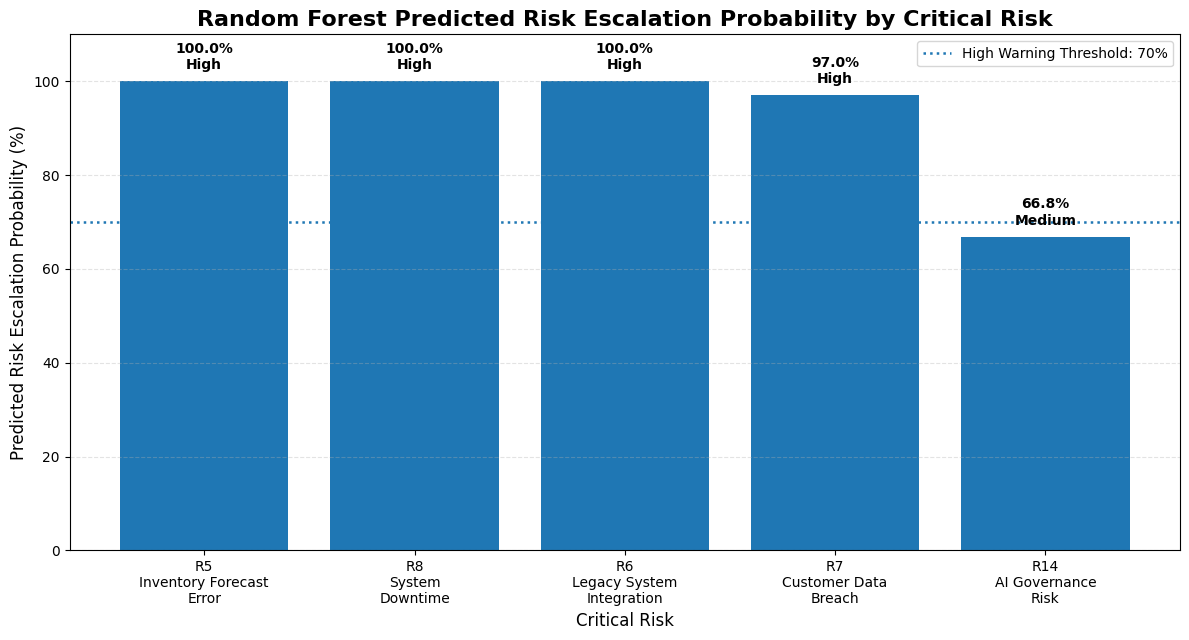

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# =========================
# Use summary_table from previous output
# If your probability column is string like "100.0%", convert it back
# =========================

plot_df = summary_table.copy()

plot_df["Predicted_Prob_Num"] = (
    plot_df["Predicted_High_Risk_Probability"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

# Sort from high to low
plot_df = plot_df.sort_values("Predicted_Prob_Num", ascending=False)

# Short labels for PPT
label_map = {
    "R5": "R5\nInventory Forecast\nError",
    "R8": "R8\nSystem\nDowntime",
    "R6": "R6\nLegacy System\nIntegration",
    "R7": "R7\nCustomer Data\nBreach",
    "R14": "R14\nAI Governance\nRisk"
}

plot_df["Label"] = plot_df["Risk_ID"].map(label_map)

# Classification label
def warning_level(x):
    if x >= 70:
        return "High"
    elif x >= 40:
        return "Medium"
    else:
        return "Low"

plot_df["Warning_Level"] = plot_df["Predicted_Prob_Num"].apply(warning_level)

# =========================
# Plot
# =========================

fig, ax = plt.subplots(figsize=(12, 6.5))

bars = ax.bar(
    plot_df["Label"],
    plot_df["Predicted_Prob_Num"]
)

# Threshold line
threshold = 70
ax.axhline(
    threshold,
    linestyle=":",
    linewidth=1.8,
    label="High Warning Threshold: 70%"
)

# Labels on bars
for bar, prob, level in zip(bars, plot_df["Predicted_Prob_Num"], plot_df["Warning_Level"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{prob:.1f}%\n{level}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Title and labels
ax.set_title(
    "Random Forest Predicted Risk Escalation Probability by Critical Risk",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Predicted Risk Escalation Probability (%)", fontsize=12)
ax.set_xlabel("Critical Risk", fontsize=12)

ax.set_ylim(0, 110)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(loc="upper right")

plt.tight_layout()

plt.savefig(
    "rf_predicted_escalation_probability_5_critical_risks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

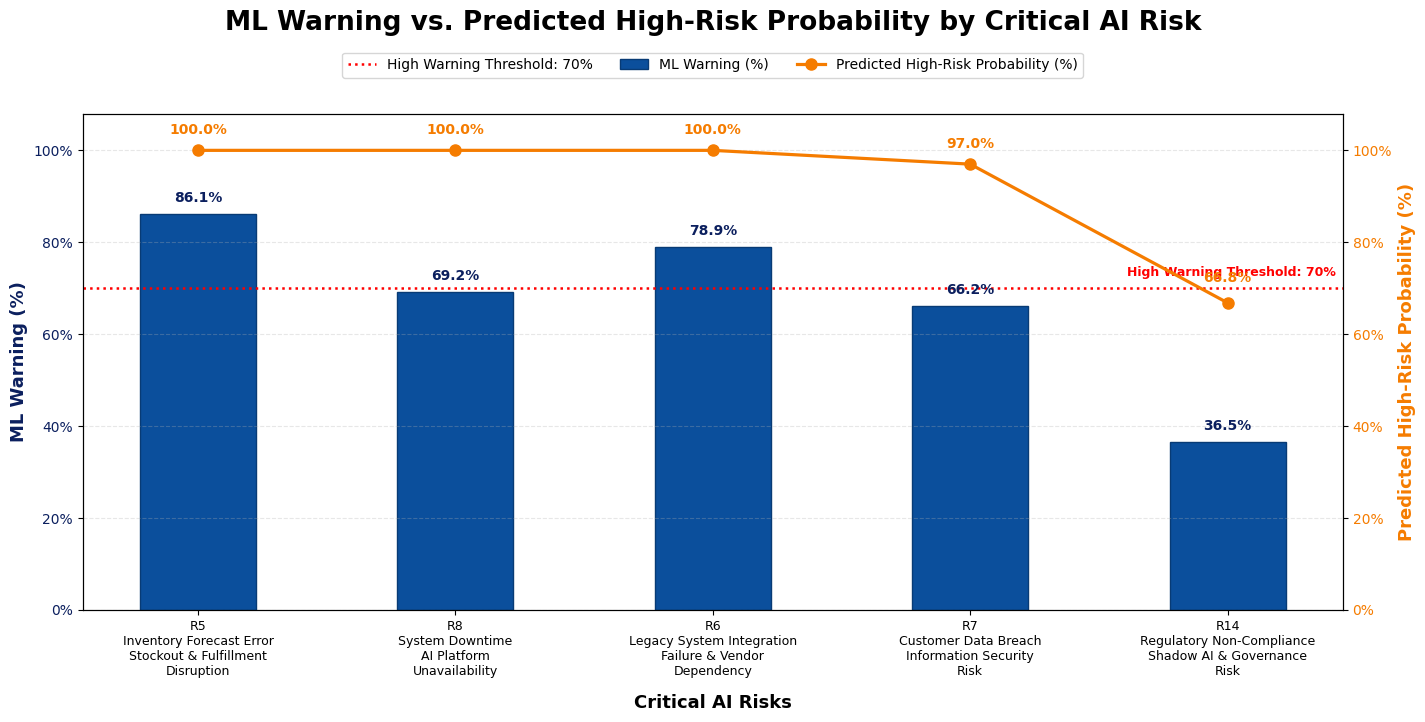

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data
# =========================
risk_ids = ["R5", "R8", "R6", "R7", "R14"]

risk_labels = [
    "R5\nInventory Forecast Error\nStockout & Fulfillment\nDisruption",
    "R8\nSystem Downtime\nAI Platform\nUnavailability",
    "R6\nLegacy System Integration\nFailure & Vendor\nDependency",
    "R7\nCustomer Data Breach\nInformation Security\nRisk",
    "R14\nRegulatory Non-Compliance\nShadow AI & Governance\nRisk"
]

ml_warning = np.array([86.1, 69.2, 78.9, 66.2, 36.5])
predicted_prob = np.array([100.0, 100.0, 100.0, 97.0, 66.8])

x = np.arange(len(risk_ids))

# =========================
# Figure
# =========================
fig, ax1 = plt.subplots(figsize=(15, 8))

# Bar: ML Warning
bars = ax1.bar(
    x,
    ml_warning,
    width=0.45,
    color="#0B4F9C",
    edgecolor="#083B75",
    label="ML Warning (%)"
)

ax1.set_ylabel("ML Warning (%)", fontsize=13, fontweight="bold", color="#0B1F5E")
ax1.set_ylim(0, 108)
ax1.set_yticks(np.arange(0, 101, 20))
ax1.set_yticklabels([f"{i}%" for i in range(0, 101, 20)])
ax1.tick_params(axis="y", labelcolor="#0B1F5E")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(risk_labels, fontsize=9)
ax1.set_xlabel("Critical AI Risks", fontsize=13, fontweight="bold", labelpad=12)

# Bar labels
for bar, value in zip(bars, ml_warning):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#0B1F5E"
    )

# Threshold line
threshold = 70
ax1.axhline(
    threshold,
    color="red",
    linestyle=":",
    linewidth=1.8,
    label="High Warning Threshold: 70%"
)

ax1.text(
    4.42,
    threshold + 2,
    "High Warning Threshold: 70%",
    ha="right",
    va="bottom",
    fontsize=9,
    fontweight="bold",
    color="red"
)

# Line: Predicted High-Risk Probability
ax2 = ax1.twinx()

line = ax2.plot(
    x,
    predicted_prob,
    marker="o",
    markersize=8,
    linewidth=2.3,
    color="#F57C00",
    label="Predicted High-Risk Probability (%)"
)

ax2.set_ylabel(
    "Predicted High-Risk Probability (%)",
    fontsize=13,
    fontweight="bold",
    color="#F57C00"
)
ax2.set_ylim(0, 108)
ax2.set_yticks(np.arange(0, 101, 20))
ax2.set_yticklabels([f"{i}%" for i in range(0, 101, 20)])
ax2.tick_params(axis="y", labelcolor="#F57C00")

# Line labels
for i, value in enumerate(predicted_prob):
    y_offset = 3
    if risk_ids[i] == "R14":
        y_offset = 4
    ax2.text(
        x[i],
        value + y_offset,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#F57C00"
    )

# Title
fig.suptitle(
    "ML Warning vs. Predicted High-Risk Probability by Critical AI Risk",
    fontsize=19,
    fontweight="bold",
    y=0.97
)

# Legend below title, no overlap
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.925),
    ncol=3,
    frameon=True,
    fontsize=10
)

# Space adjustment
plt.subplots_adjust(
    top=0.84,
    bottom=0.22,
    left=0.08,
    right=0.92
)

# Save
plt.savefig(
    "ml_warning_vs_predicted_probability_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

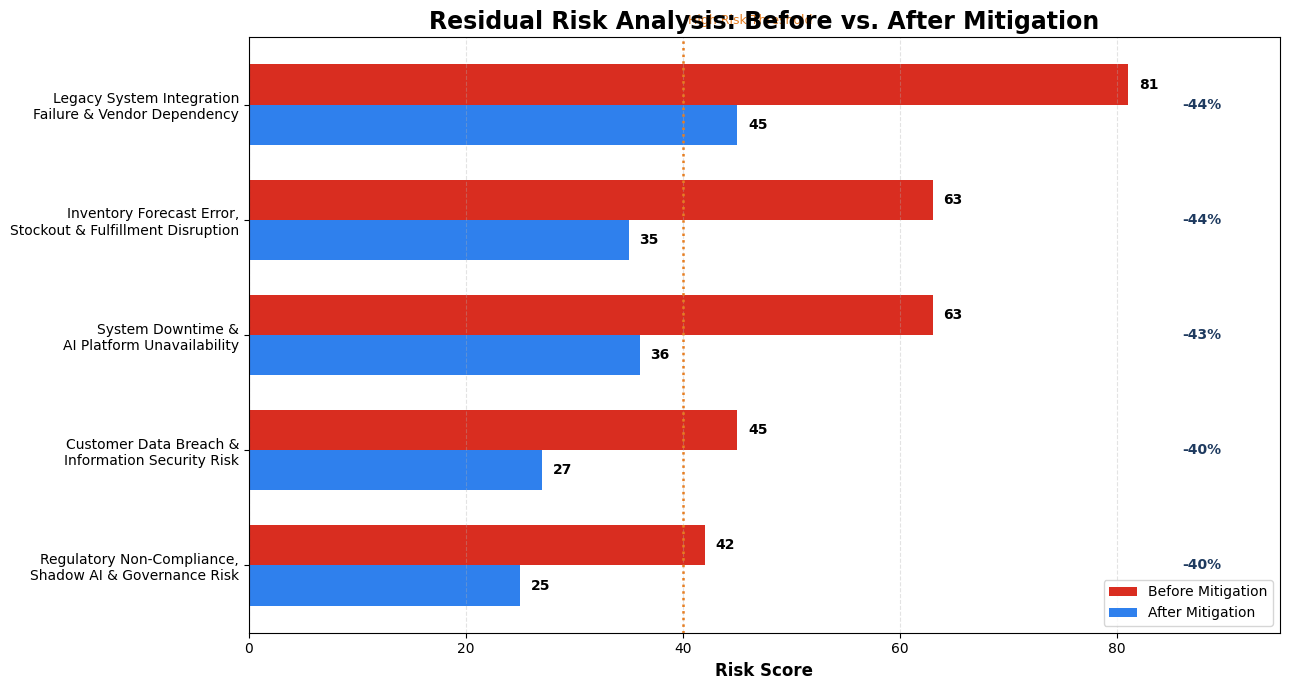

,Risk_ID,Before_Likelihood,Before_Impact,Before_Risk_Score,After_Likelihood,After_Impact,After_Risk_Score,Reduction_%
4,R14,7,6,42,5,5,25,40.476190
3,R7,5,9,45,3,9,27,40.000000
2,R8,7,9,63,4,9,36,42.857143
1,R5,7,9,63,5,7,35,44.444444
0,R6,9,9,81,5,9,45,44.444444


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# Residual Risk Data
# Based on latest Risk Register + mitigation assumptions
# =========================

data = pd.DataFrame({
    "Risk_ID": ["R6", "R5", "R8", "R7", "R14"],
    "Risk": [
        "Legacy System Integration\nFailure & Vendor Dependency",
        "Inventory Forecast Error,\nStockout & Fulfillment Disruption",
        "System Downtime &\nAI Platform Unavailability",
        "Customer Data Breach &\nInformation Security Risk",
        "Regulatory Non-Compliance,\nShadow AI & Governance Risk"
    ],
    "Before_Likelihood": [9, 7, 7, 5, 7],
    "Before_Impact": [9, 9, 9, 9, 6],
    "After_Likelihood": [5, 5, 4, 3, 5],
    "After_Impact": [9, 7, 9, 9, 5]
})

data["Before_Risk_Score"] = data["Before_Likelihood"] * data["Before_Impact"]
data["After_Risk_Score"] = data["After_Likelihood"] * data["After_Impact"]
data["Reduction_%"] = (
    (data["Before_Risk_Score"] - data["After_Risk_Score"]) 
    / data["Before_Risk_Score"] * 100
)

# Sort by original risk score
data = data.sort_values("Before_Risk_Score", ascending=True)

# =========================
# Plot
# =========================

plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(13, 7))

y = np.arange(len(data))
bar_height = 0.35

ax.barh(
    y + bar_height / 2,
    data["Before_Risk_Score"],
    height=bar_height,
    label="Before Mitigation",
    color="#D92D20"
)

ax.barh(
    y - bar_height / 2,
    data["After_Risk_Score"],
    height=bar_height,
    label="After Mitigation",
    color="#2F80ED"
)

# Labels
for i, row in data.iterrows():
    idx = list(data.index).index(i)

    ax.text(
        row["Before_Risk_Score"] + 1,
        idx + bar_height / 2,
        f"{int(row['Before_Risk_Score'])}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        row["After_Risk_Score"] + 1,
        idx - bar_height / 2,
        f"{int(row['After_Risk_Score'])}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        86,
        idx,
        f"-{row['Reduction_%']:.0f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#1E3A5F"
    )

ax.set_yticks(y)
ax.set_yticklabels(data["Risk"], fontsize=10)

ax.set_xlabel("Risk Score", fontsize=12, fontweight="bold")
ax.set_title(
    "Residual Risk Analysis: Before vs. After Mitigation",
    fontsize=17,
    fontweight="bold"
)

ax.set_xlim(0, 95)
ax.grid(axis="x", linestyle="--", alpha=0.35)

ax.legend(loc="lower right")

# Threshold lines
ax.axvline(40, linestyle=":", linewidth=1.8, color="#E67E22")
ax.text(40.5, len(data)-0.3, "High Risk Threshold", fontsize=9, color="#E67E22")

plt.tight_layout()

plt.savefig(
    "residual_risk_before_after_mitigation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

data[[
    "Risk_ID",
    "Before_Likelihood",
    "Before_Impact",
    "Before_Risk_Score",
    "After_Likelihood",
    "After_Impact",
    "After_Risk_Score",
    "Reduction_%"
]]